# 1.Ultralytics installation

In [ ]:

!pip install -U ultralytics

import os
import yaml
from ultralytics import YOLO
import torch


device = '0' if torch.cuda.is_available() else 'cpu'
print(f"Sistemul rulează pe: {device} ({torch.cuda.get_device_name(0) if device=='0' else 'CPU'})")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:000:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvj

# 2.Dataset Configuration


In [2]:
import os

base = '/kaggle/input/bone-fracture-detection-computer-vision-project'

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} fișiere)")

bone-fracture-detection-computer-vision-project/  (0 fișiere)
  bone fracture detection.v4-v4.yolov8/  (2 fișiere)
    valid/  (0 fișiere)
      labels/  (348 fișiere)
      images/  (348 fișiere)
    test/  (0 fișiere)
      labels/  (169 fișiere)
      images/  (169 fișiere)
    train/  (0 fișiere)
      labels/  (3631 fișiere)
      images/  (3631 fișiere)
  BoneFractureYolo8/  (2 fișiere)
    valid/  (0 fișiere)
      labels/  (348 fișiere)
      images/  (348 fișiere)
    test/  (0 fișiere)
      labels/  (169 fișiere)
      images/  (169 fișiere)
    train/  (0 fișiere)
      labels/  (3631 fișiere)
      images/  (3631 fișiere)


In [ ]:
import os

dataset_root = '/kaggle/input/bone-fracture-detection-computer-vision/BoneFractureYolo8'


for root, dirs, files in os.walk(dataset_root):
    level = root.replace(dataset_root, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        print(f"{'  ' * (level+1)}→ {len(files)} fișiere")

In [ ]:
import yaml, os

dataset_root = '/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8'

data_config = {
    'train': f'{dataset_root}/train/images',
    'val':   f'{dataset_root}/valid/images',
    'test':  f'{dataset_root}/test/images',
    'nc': 7,
    'names': [
        'elbow positive',
        'fingers positive', 
        'forearm fracture',
        'humerus fracture',
        'humerus',
        'shoulder fracture',
        'wrist positive'
    ]
}

yaml_path = '/kaggle/working/bone_data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, allow_unicode=True)

print("YAML actualizat cu 7 clase")
with open(yaml_path) as f:
    print(f.read())

✅ YAML actualizat cu 7 clase
names:
- elbow positive
- fingers positive
- forearm fracture
- humerus fracture
- humerus
- shoulder fracture
- wrist positive
nc: 7
test: /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images
train: /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/train/images
val: /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/valid/images



# 3. Model Training (YOLOv8)



In [5]:



from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/kaggle/working/bone_data.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    device='0',
    project='/kaggle/working/runs',
    name='bone_fracture_v2',
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.1,
    mosaic=1.0,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    patience=15,
    save=True,
    exist_ok=True,
    verbose=True
)

Ultralytics 8.4.75 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bone_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bone_fracture_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        348        204      0.411       0.27      0.277      0.108
        elbow positive         28         29      0.292      0.241      0.143     0.0461
      fingers positive         41         48      0.565      0.104      0.236     0.0779
      forearm fracture         37         43      0.464      0.558      0.477      0.199
               humerus         31         36      0.487      0.528      0.539      0.213
     shoulder fracture         19         20      0.458       0.15      0.206     0.0988
        wrist positive         17         28      0.201     0.0361     0.0625     0.0157
Speed: 0.2ms preprocess, 12.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/bone_fracture_v2


# 4. Model Evaluation and Analysis

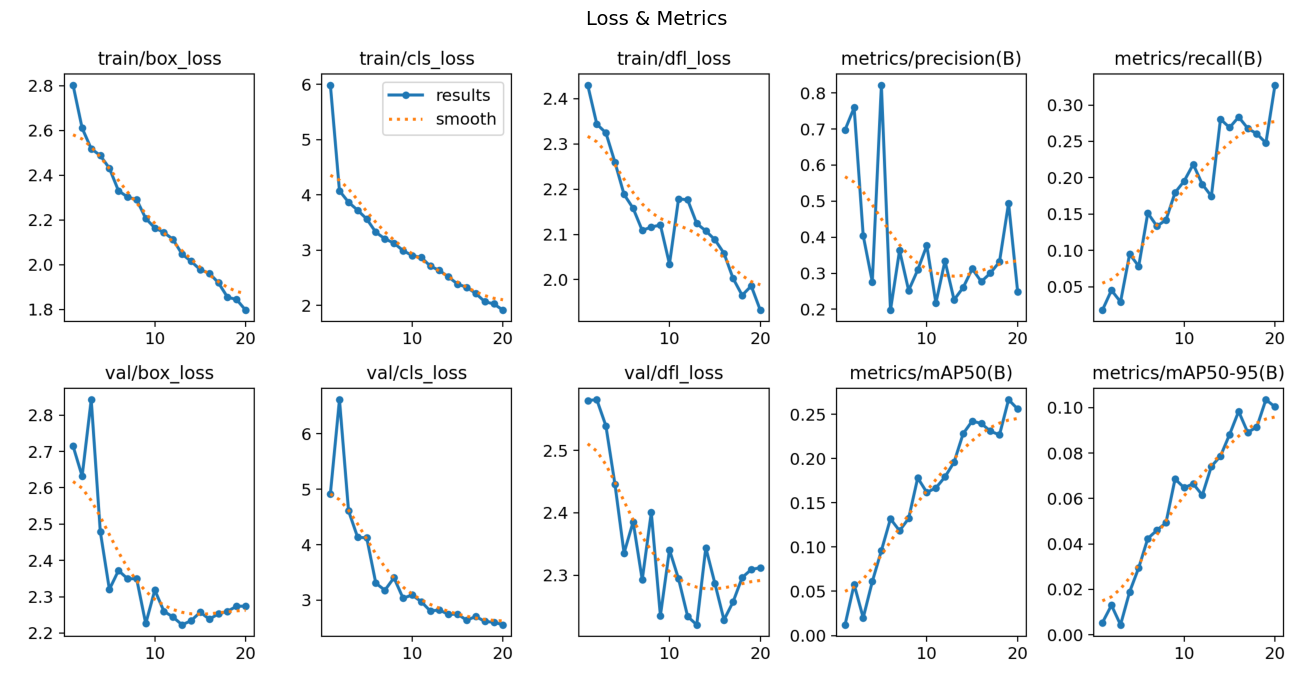

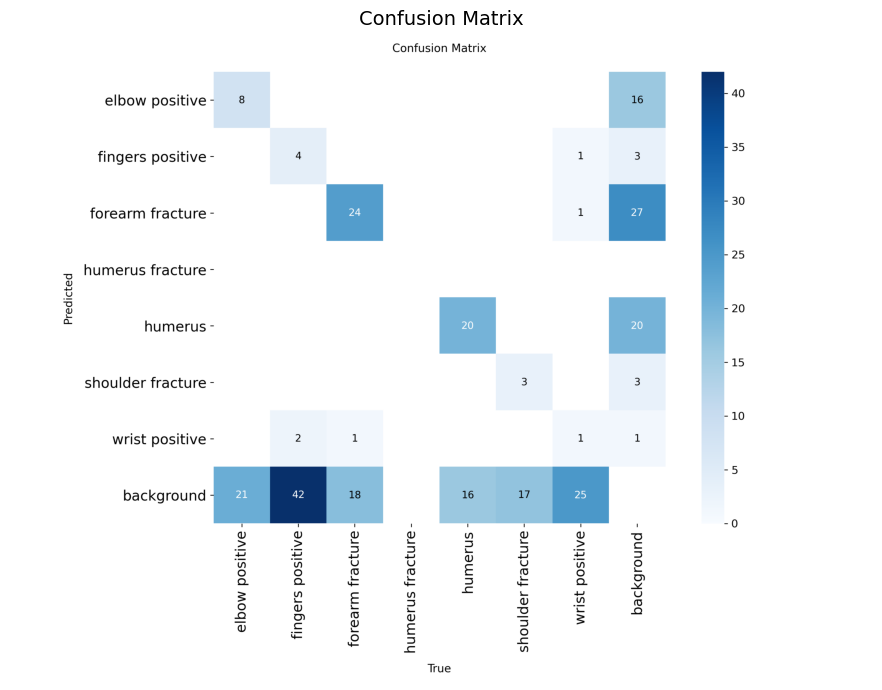


image 1/1 /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images/image1_2263_png.rf.43688af1368a72ad0bc6719a5dcab20b.jpg: 640x608 (no detections), 48.8ms
Speed: 2.7ms preprocess, 48.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 608)

image 1/1 /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images/image1_211_png.rf.e1fd0ca40a197d13f9ecae59c4074d43.jpg: 640x512 (no detections), 49.9ms
Speed: 2.3ms preprocess, 49.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images/image1_497_png.rf.d6769296bd5c7ac8218ae363a5dc3968.jpg: 640x384 (no detections), 48.5ms
Speed: 1.8ms preprocess, 48.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images/image1_639_png.rf.915590376683da

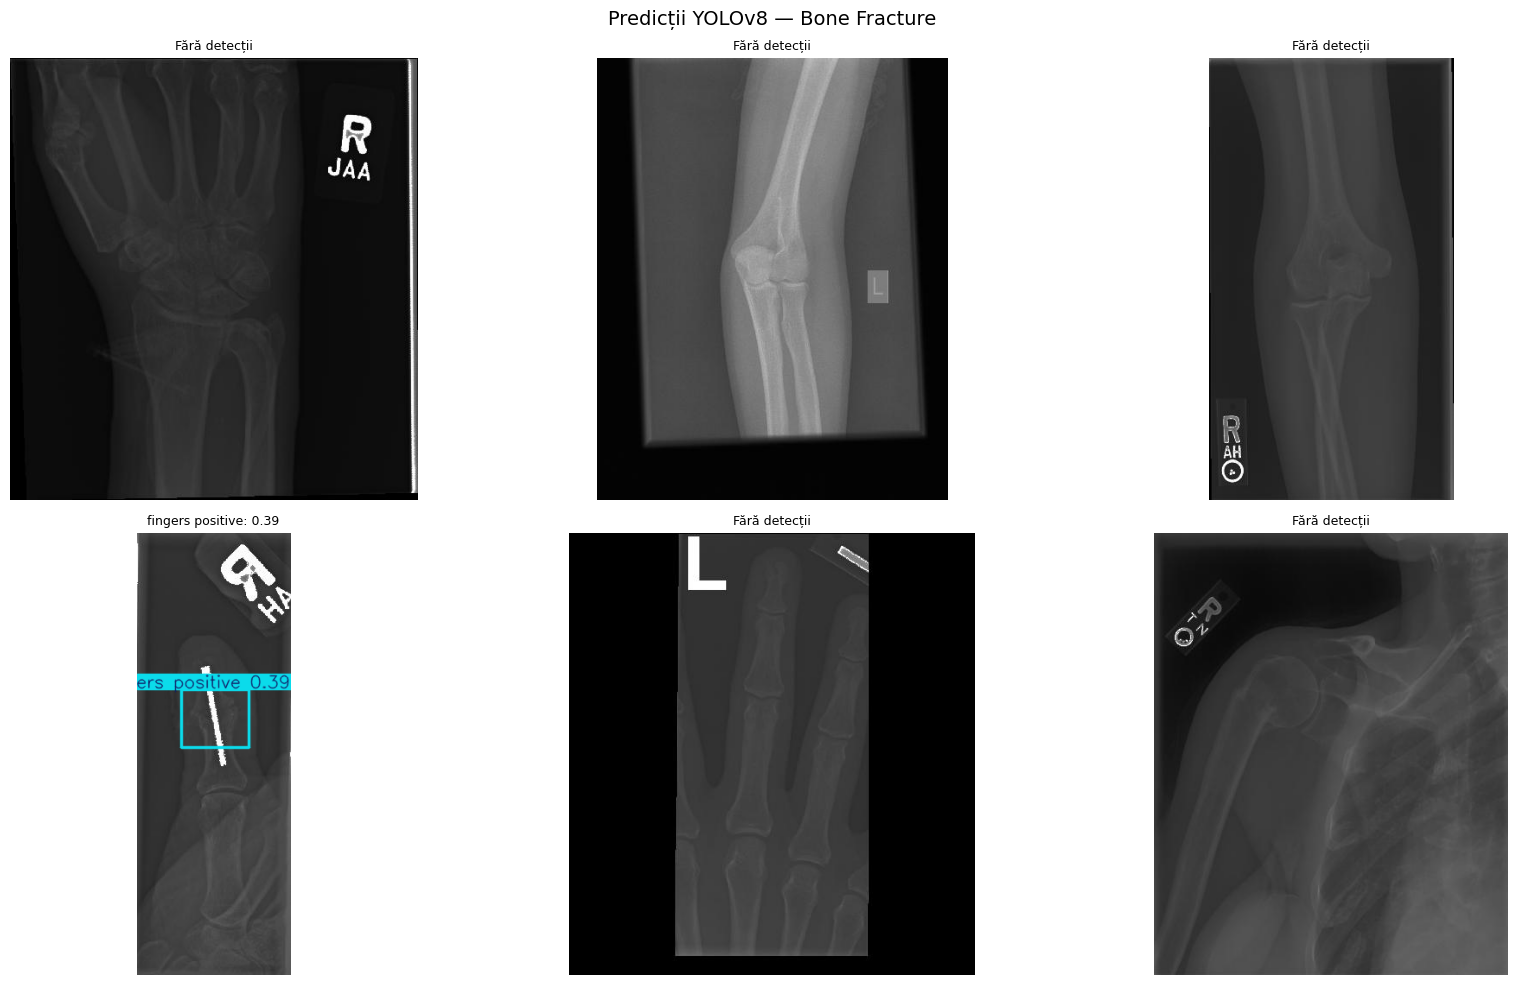

In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, random, cv2, os

model = YOLO('/kaggle/working/runs/bone_fracture_v2/weights/best.pt')

# Grafice antrenare
results_dir = '/kaggle/working/runs/bone_fracture_v2'
for filename, title in [
    ('results.png',          'Loss & Metrics'),
    ('confusion_matrix.png', 'Confusion Matrix'),
    ('PR_curve.png',         'PR Curve'),
    ('F1_curve.png',         'F1 Curve'),
]:
    path = os.path.join(results_dir, filename)
    if os.path.exists(path):
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(mpimg.imread(path))
        ax.axis('off')
        ax.set_title(title, fontsize=14)
        plt.tight_layout()
        plt.show()

# Predicții vizuale pe test
names = ['elbow positive', 'fingers positive', 'forearm fracture',
         'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']

test_images = glob.glob('/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/images/*')
sample = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, img_path in enumerate(sample):
    results = model(img_path, conf=0.25, iou=0.45)[0]
    annotated = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)
    axes.flatten()[idx].imshow(annotated)
    axes.flatten()[idx].axis('off')
    detections = [f"{names[int(b.cls)]}: {float(b.conf):.2f}" for b in results.boxes] or ['Fără detecții']
    axes.flatten()[idx].set_title(' | '.join(detections), fontsize=9)

plt.suptitle('Predicții YOLOv8 — Bone Fracture', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/predictions_sample.png', dpi=150, bbox_inches='tight')
plt.show()